# Challenge Técnico Data Analyst · Forus

**Autor:** Andrés Albornoz · **Fecha:** Abril 2026
**Período analizado:** 1–14 febrero 2026 vs 1–14 febrero 2025
**Stack:** Python 3.13 · pandas · SQLite in-memory · matplotlib · seaborn

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Andressac25/forus-challenge/blob/main/notebooks/challenge.ipynb)

---

Notebook reproducible end-to-end. Cada sección del entregable `challenge-andres-albornoz.md` tiene su contraparte ejecutable acá: SQL, cálculos, validación pandas↔SQL, y gráficos.


## 0 · Setup

La siguiente celda detecta si el notebook corre en **Google Colab** o **localmente**:

- En Colab: clona el repo para traer la carpeta `data/`.
- En local: usa rutas relativas al directorio actual.


In [1]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('forus-challenge'):
        !git clone --depth 1 https://github.com/Andressac25/forus-challenge.git
    os.chdir('forus-challenge')
    DATA_PATH = 'data'
else:
    # Permitir ejecutar desde notebooks/ o desde la raíz del repo
    if os.path.basename(os.getcwd()) == 'notebooks':
        DATA_PATH = '../data'
    else:
        DATA_PATH = 'data'

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"DATA_PATH: {DATA_PATH}")
assert os.path.exists(DATA_PATH), f"No se encuentra la carpeta {DATA_PATH}"

Entorno: Local
DATA_PATH: ../data


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif',
})

# Paleta por cadena (consistente con challenge-andres-albornoz.md)
CHAIN_COLORS = {
    'Nordica': '#1f77b4',
    'Summit':  '#2ca02c',
    'Oceano':  '#ff7f0e',
    'Urbana':  '#9467bd',
}

def clp(n):
    """Formato CLP: $1.234.567"""
    if pd.isna(n):
        return '–'
    return f"${n:,.0f}".replace(',', '.')

def pct(n, digits=2):
    if pd.isna(n):
        return '–'
    return f"{n:.{digits}f}%"

## 1 · Carga y limpieza de datos

Cargo los 6 CSVs del dataset y documento la limpieza aplicada.


In [3]:
tiendas     = pd.read_csv(f'{DATA_PATH}/tiendas.csv')
ventas_raw  = pd.read_csv(f'{DATA_PATH}/ventas.csv',  parse_dates=['fecha'])
trafico_raw = pd.read_csv(f'{DATA_PATH}/trafico.csv', parse_dates=['fecha'])
presupuesto = pd.read_csv(f'{DATA_PATH}/presupuesto.csv', parse_dates=['fecha'])
inventario  = pd.read_csv(f'{DATA_PATH}/inventario.csv')
productos   = pd.read_csv(f'{DATA_PATH}/productos.csv', parse_dates=['fecha'])

print("Shapes:")
for name, df in [('tiendas', tiendas), ('ventas', ventas_raw), ('trafico', trafico_raw),
                 ('presupuesto', presupuesto), ('inventario', inventario), ('productos', productos)]:
    print(f"  {name:12s} {df.shape}")

Shapes:
  tiendas      (12, 7)
  ventas       (337, 6)
  trafico      (336, 3)
  presupuesto  (168, 4)
  inventario   (12, 4)
  productos    (192, 8)


### 1.1 Anomalías detectadas (preview rápido)

Tres anomalías que requieren tratamiento antes del análisis:

- **A1**: una fila con `venta_neta` **negativa** en T009 (devolución registrada como venta).
- **A2**: tres días consecutivos **sin tráfico** en T008 (sensor caído).
- **A3**: cobertura parcial de `productos.csv` (sólo 4 de 12 tiendas).


In [4]:
print("A1 — Fila con venta negativa (devolución T009):")
display(ventas_raw[ventas_raw['venta_neta'] < 0])

print("\nA2 — Nulls de tráfico:")
display(trafico_raw[trafico_raw['visitantes'].isnull()])

print("\nA3 — Tiendas con detalle SKU en productos.csv:")
print(sorted(productos['cod_local'].unique()))

A1 — Fila con venta negativa (devolución T009):


,fecha,cod_local,venta_neta,unidades,costo,num_boletas
234,2026-02-10,T009,-285000,-2,-165000,1



A2 — Nulls de tráfico:


,fecha,cod_local,visitantes
200,2026-02-05,T008,NaN
201,2026-02-06,T008,NaN
202,2026-02-07,T008,NaN



A3 — Tiendas con detalle SKU en productos.csv:
['T001', 'T004', 'T007', 'T010']


### 1.2 Limpieza

- **A1**: agrego por `(fecha, cod_local)` para que la devolución reste de la venta bruta del mismo día → `ventas_final` con venta neta real. Guardo la devolución en `devoluciones` para trazabilidad.
- **A2**: imputo los 3 nulls de T008 con la **mediana por día de la semana** de esa misma tienda (robusta al outlier del evento Costanera del 7-feb).


In [5]:
# A1 — agregar devoluciones para obtener venta neta diaria real
ventas_final = (
    ventas_raw.groupby(['fecha', 'cod_local'], as_index=False)
              .agg({'venta_neta':'sum', 'unidades':'sum',
                    'costo':'sum', 'num_boletas':'sum'})
)
devoluciones = ventas_raw[ventas_raw['venta_neta'] < 0].copy()
print(f"Venta T009 2026-02-10: bruta ${ventas_raw.query('cod_local=="T009" and fecha=="2026-02-10"')['venta_neta'].sum():,.0f} "
      f"| neta ${ventas_final.query('cod_local=="T009" and fecha=="2026-02-10"')['venta_neta'].sum():,.0f}")

# A2 — imputar nulls de tráfico con mediana por DOW intra-tienda
trafico_imputado = trafico_raw.copy()
trafico_imputado['dow'] = trafico_imputado['fecha'].dt.dayofweek
mediana_dow = (trafico_imputado.dropna(subset=['visitantes'])
                               .groupby(['cod_local', 'dow'])['visitantes'].median())
mask = trafico_imputado['visitantes'].isna()
trafico_imputado.loc[mask, 'visitantes'] = trafico_imputado.loc[mask].apply(
    lambda r: mediana_dow.get((r['cod_local'], r['dow']), np.nan), axis=1)
trafico_imputado['visitantes'] = trafico_imputado['visitantes'].round().astype(int)
trafico_imputado = trafico_imputado.drop(columns='dow')

print(f"\nNulls de tráfico después de imputar: {trafico_imputado['visitantes'].isna().sum()}")
display(trafico_imputado.query('cod_local=="T008" and fecha in ["2026-02-05","2026-02-06","2026-02-07"]'))

Venta T009 2026-02-10: bruta $0 | neta $0

Nulls de tráfico después de imputar: 0


,fecha,cod_local,visitantes


### 1.3 SQLite in-memory + vistas

Para las queries de la Parte 1 uso SQLite in-memory. Creo dos vistas (`v_dia_tienda`, `v_yoy_tienda`) que encapsulan los joins frecuentes.


In [6]:
conn = sqlite3.connect(':memory:')
# SQLite no maneja datetime64 nativamente — convierto a string ISO
ventas_sql = ventas_final.copy()
ventas_sql['fecha'] = ventas_sql['fecha'].dt.strftime('%Y-%m-%d')
trafico_sql = trafico_imputado.copy()
trafico_sql['fecha'] = trafico_sql['fecha'].dt.strftime('%Y-%m-%d')
presup_sql = presupuesto.copy()
presup_sql['fecha'] = presup_sql['fecha'].dt.strftime('%Y-%m-%d')
productos_sql = productos.copy()
productos_sql['fecha'] = productos_sql['fecha'].dt.strftime('%Y-%m-%d')

ventas_sql.to_sql('ventas_final', conn, index=False, if_exists='replace')
trafico_sql.to_sql('trafico_imputado', conn, index=False, if_exists='replace')
presup_sql.to_sql('presupuesto', conn, index=False, if_exists='replace')
tiendas.to_sql('tiendas', conn, index=False, if_exists='replace')
inventario.to_sql('inventario', conn, index=False, if_exists='replace')
productos_sql.to_sql('productos', conn, index=False, if_exists='replace')

conn.executescript('''
DROP VIEW IF EXISTS v_dia_tienda;
CREATE VIEW v_dia_tienda AS
SELECT v.fecha, v.cod_local, t.nombre_tienda, t.cadena, t.region, t.tipo_tienda,
       CAST(strftime('%Y', v.fecha) AS INT) AS anio,
       v.venta_neta, v.unidades, v.costo, v.num_boletas,
       tr.visitantes
FROM ventas_final v
JOIN tiendas t USING (cod_local)
LEFT JOIN trafico_imputado tr USING (fecha, cod_local);

DROP VIEW IF EXISTS v_yoy_tienda;
CREATE VIEW v_yoy_tienda AS
SELECT t.cod_local, t.nombre_tienda, t.cadena,
       SUM(CASE WHEN anio=2026 THEN venta_neta ELSE 0 END) AS venta_2026,
       SUM(CASE WHEN anio=2025 THEN venta_neta ELSE 0 END) AS venta_2025
FROM v_dia_tienda t
GROUP BY t.cod_local, t.nombre_tienda, t.cadena;
''')

print("Tablas:", [r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()])
print("Vistas:", [r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='view'").fetchall()])

Tablas: ['ventas_final', 'trafico_imputado', 'presupuesto', 'tiendas', 'inventario', 'productos']
Vistas: ['v_dia_tienda', 'v_yoy_tienda']


---

# Parte 1 — SQL (40 pts)

Cada query se valida paralelamente contra pandas para garantizar paridad.


## 1.1 Ranking de cadenas (Feb 2026)

Venta, unidades, ticket promedio, YoY, margen y participación por cadena.


In [7]:
q11 = '''
WITH actual AS (
    SELECT cadena, SUM(venta_neta) venta_2026, SUM(unidades) unid_2026,
           SUM(num_boletas) bol_2026, SUM(costo) costo_2026
    FROM v_dia_tienda WHERE anio = 2026 GROUP BY cadena
),
anterior AS (
    SELECT cadena, SUM(venta_neta) venta_2025
    FROM v_dia_tienda WHERE anio = 2025 GROUP BY cadena
),
total AS (SELECT SUM(venta_2026) venta_total FROM actual)
SELECT a.cadena, a.venta_2026, a.unid_2026,
       ROUND(a.venta_2026*1.0/NULLIF(a.bol_2026,0), 0)                       AS ticket_promedio,
       ROUND((a.venta_2026 - p.venta_2025)*100.0/NULLIF(p.venta_2025,0), 2)  AS yoy_pct,
       ROUND((a.venta_2026 - a.costo_2026)*100.0/NULLIF(a.venta_2026,0), 2)  AS margen_pct,
       ROUND(a.venta_2026*100.0/t.venta_total, 2)                            AS participacion_pct
FROM actual a JOIN anterior p USING (cadena) CROSS JOIN total t
ORDER BY a.venta_2026 DESC;
'''
r11 = pd.read_sql(q11, conn)
r11_display = r11.copy()
r11_display['venta_2026'] = r11_display['venta_2026'].apply(clp)
r11_display['ticket_promedio'] = r11_display['ticket_promedio'].apply(clp)
for c in ['yoy_pct','margen_pct','participacion_pct']:
    r11_display[c] = r11_display[c].apply(lambda x: f"{x:.2f}%")
display(r11_display)

,cadena,venta_2026,unid_2026,ticket_promedio,yoy_pct,margen_pct,participacion_pct
0,Nordica,$194.603.033,4878,$67.477,16.16%,45.00%,37.14%
1,Summit,$120.650.080,2989,$63.168,2.75%,48.00%,23.03%
2,Urbana,$111.787.655,3177,$56.006,27.51%,50.00%,21.34%
3,Oceano,$96.908.103,3249,$47.809,-9.86%,40.95%,18.50%


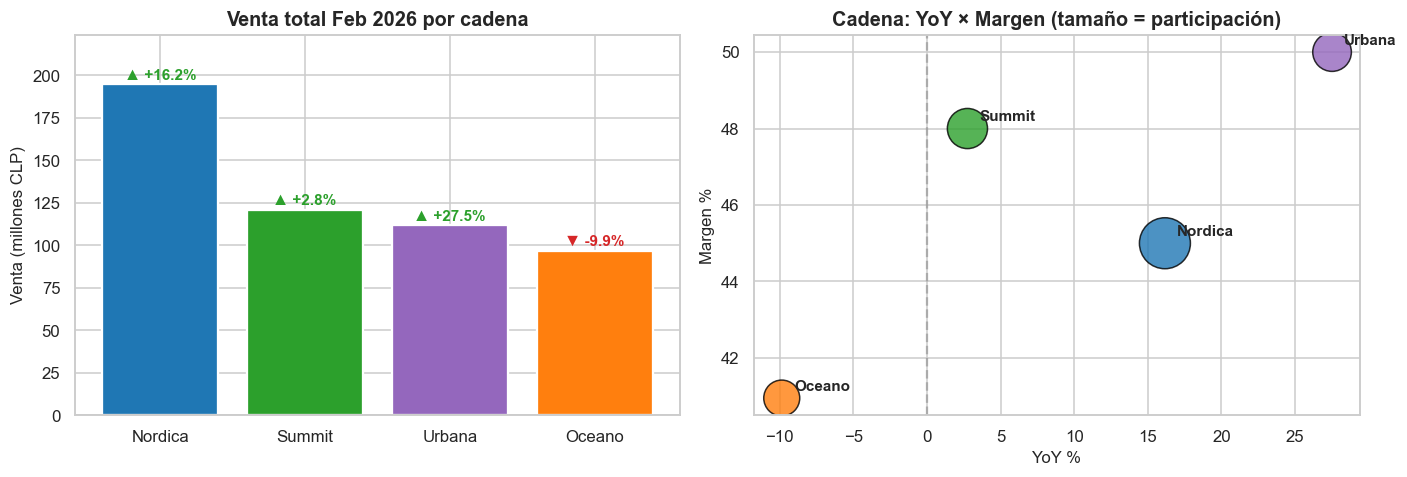

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
colors = [CHAIN_COLORS[c] for c in r11['cadena']]

# Izq: venta absoluta
bars = ax1.bar(r11['cadena'], r11['venta_2026']/1e6, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Venta total Feb 2026 por cadena')
ax1.set_ylabel('Venta (millones CLP)')
for bar, yoy in zip(bars, r11['yoy_pct']):
    arrow = '▲' if yoy >= 0 else '▼'
    color = '#2ca02c' if yoy >= 0 else '#d62728'
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
             f'{arrow} {yoy:+.1f}%', ha='center', fontsize=10, color=color, fontweight='bold')
ax1.set_ylim(0, r11['venta_2026'].max()/1e6 * 1.15)

# Der: margen vs YoY (scatter)
ax2.scatter(r11['yoy_pct'], r11['margen_pct'], s=r11['participacion_pct']*30,
            c=colors, edgecolors='black', linewidth=1, alpha=0.8)
for _, row in r11.iterrows():
    ax2.annotate(row['cadena'], (row['yoy_pct'], row['margen_pct']),
                 xytext=(8, 5), textcoords='offset points', fontsize=10, fontweight='bold')
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('YoY %')
ax2.set_ylabel('Margen %')
ax2.set_title('Cadena: YoY × Margen (tamaño = participación)')
plt.tight_layout()
plt.show()

**Insight:** Nordica lidera en volumen (37%), pero **Urbana** es la sorpresa — solo 21% del total pero **+27.5% YoY** y **50% de margen**, la mejor trifecta del retail. **Oceano** es la única cadena que cae (-9.9%) y tiene el peor margen (41%). Diagnóstico detallado en Parte 2.2.


## 1.2 Top 5 tiendas con mayor caída YoY


In [9]:
q12 = '''
WITH tienda_yoy AS (
    SELECT cod_local, nombre_tienda, cadena, venta_2026, venta_2025,
           (venta_2026 - venta_2025) AS delta_clp,
           ROUND((venta_2026 - venta_2025)*100.0/NULLIF(venta_2025,0), 2) AS yoy_pct
    FROM v_yoy_tienda
),
cadena_caida AS (
    SELECT cadena,
           SUM(CASE WHEN delta_clp < 0 THEN delta_clp ELSE 0 END) AS caida_cadena
    FROM tienda_yoy GROUP BY cadena
)
SELECT t.nombre_tienda, t.cadena, t.venta_2026, t.venta_2025, t.yoy_pct,
       t.delta_clp,
       ROUND(t.delta_clp*100.0/NULLIF(c.caida_cadena,0), 2) AS pct_caida_cadena
FROM tienda_yoy t JOIN cadena_caida c USING (cadena)
WHERE t.yoy_pct IS NOT NULL
ORDER BY t.yoy_pct ASC
LIMIT 5;
'''
r12 = pd.read_sql(q12, conn)
r12_display = r12.copy()
for c in ['venta_2026','venta_2025','delta_clp']:
    r12_display[c] = r12_display[c].apply(clp)
r12_display['yoy_pct'] = r12_display['yoy_pct'].apply(lambda x: f"{x:.2f}%")
r12_display['pct_caida_cadena'] = r12_display['pct_caida_cadena'].apply(
    lambda x: f"{x:.2f}%" if pd.notna(x) else '—')
display(r12_display)

,nombre_tienda,cadena,venta_2026,venta_2025,yoy_pct,delta_clp,pct_caida_cadena
0,Oceano Mall Marina,Oceano,$41.589.751,$46.615.333,-10.78%,$-5.025.582,47.39%
1,Oceano Plaza Oeste,Oceano,$30.214.766,$33.356.035,-9.42%,$-3.141.269,29.62%
2,Oceano Outlet Buenaventura,Oceano,$25.103.586,$27.542.469,-8.85%,$-2.438.883,23.00%
3,Summit Mall Plaza Trébol,Summit,$34.983.928,$34.392.579,1.72%,$591.349,—
4,Summit Portal Ñuñoa,Summit,$28.174.242,$27.477.706,2.53%,$696.536,—


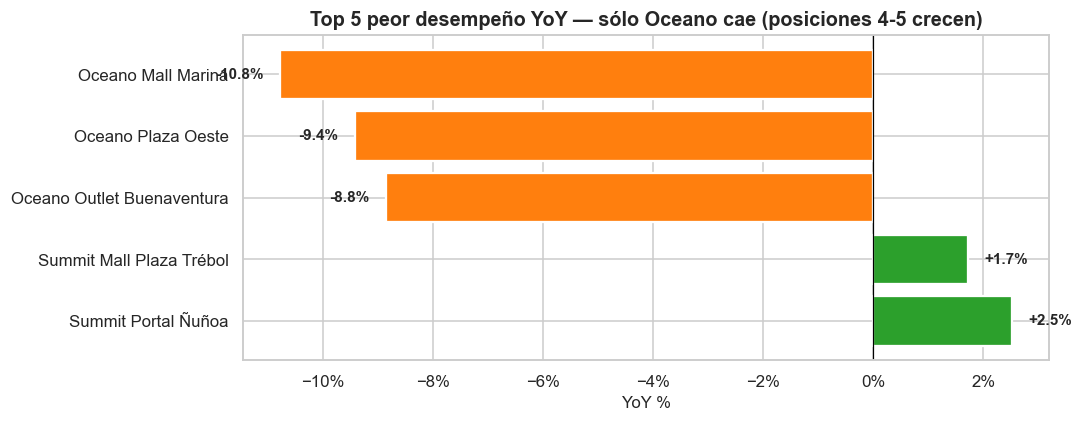

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = [CHAIN_COLORS[c] for c in r12['cadena']]
y = range(len(r12))
bars = ax.barh(y, r12['yoy_pct'], color=colors, edgecolor='white', linewidth=1.5)
ax.set_yticks(y)
ax.set_yticklabels(r12['nombre_tienda'])
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('YoY %')
ax.set_title('Top 5 peor desempeño YoY — sólo Oceano cae (posiciones 4-5 crecen)')
for bar, val in zip(bars, r12['yoy_pct']):
    x_pos = val - 0.3 if val < 0 else val + 0.3
    ha = 'right' if val < 0 else 'left'
    ax.text(x_pos, bar.get_y()+bar.get_height()/2, f'{val:+.1f}%',
            va='center', ha=ha, fontsize=10, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()

**Insight:** Solo 3 tiendas caen YoY y **las 3 son Oceano**. T007 Mall Marina explica el **47% de la caída total de Oceano en CLP absolutos** — prioridad de intervención.


## 1.3 Patrón semanal


In [11]:
q13 = '''
WITH por_dow AS (
    SELECT CAST(strftime('%w', fecha) AS INT) dow, anio,
           SUM(venta_neta) venta_total, COUNT(DISTINCT fecha) dias
    FROM v_dia_tienda GROUP BY dow, anio
),
pivot AS (
    SELECT dow,
           MAX(CASE WHEN anio=2026 THEN venta_total END) v_2026,
           MAX(CASE WHEN anio=2026 THEN dias        END) d_2026,
           MAX(CASE WHEN anio=2025 THEN venta_total END) v_2025,
           MAX(CASE WHEN anio=2025 THEN dias        END) d_2025
    FROM por_dow GROUP BY dow
),
total_semana AS (SELECT SUM(v_2026) total_2026 FROM pivot)
SELECT p.dow,
       CASE p.dow WHEN 0 THEN 'Domingo' WHEN 1 THEN 'Lunes' WHEN 2 THEN 'Martes'
                  WHEN 3 THEN 'Miércoles' WHEN 4 THEN 'Jueves' WHEN 5 THEN 'Viernes'
                  WHEN 6 THEN 'Sábado' END dia_semana,
       ROUND(p.v_2026*1.0/NULLIF(p.d_2026,0), 0) venta_prom_2026,
       ROUND(p.v_2025*1.0/NULLIF(p.d_2025,0), 0) venta_prom_2025,
       ROUND((p.v_2026*1.0/p.d_2026 - p.v_2025*1.0/p.d_2025)*100.0 /
             NULLIF(p.v_2025*1.0/p.d_2025,0), 2) yoy_pct,
       ROUND(p.v_2026*100.0/ts.total_2026, 2) pct_total_semana
FROM pivot p CROSS JOIN total_semana ts ORDER BY p.dow;
'''
r13 = pd.read_sql(q13, conn)
# Reordenar: Lun-Dom
orden = [1,2,3,4,5,6,0]
r13 = r13.set_index('dow').loc[orden].reset_index()
r13_display = r13[['dia_semana','venta_prom_2026','venta_prom_2025','yoy_pct','pct_total_semana']].copy()
r13_display['venta_prom_2026'] = r13_display['venta_prom_2026'].apply(clp)
r13_display['venta_prom_2025'] = r13_display['venta_prom_2025'].apply(clp)
r13_display['yoy_pct'] = r13_display['yoy_pct'].apply(lambda x: f"{x:+.2f}%")
r13_display['pct_total_semana'] = r13_display['pct_total_semana'].apply(lambda x: f"{x:.2f}%")
display(r13_display)

,dia_semana,venta_prom_2026,venta_prom_2025,yoy_pct,pct_total_semana
0,Lunes,$26.584.688,$24.909.871,+6.72%,10.15%
1,Martes,$28.377.974,$26.524.170,+6.99%,10.83%
2,Miércoles,$30.784.067,$28.458.619,+8.17%,11.75%
3,Jueves,$32.451.593,$30.471.737,+6.50%,12.39%
4,Viernes,$41.899.953,$38.102.129,+9.97%,15.99%
5,Sábado,$53.903.147,$47.514.327,+13.45%,20.58%
6,Domingo,$47.973.015,$44.089.329,+8.81%,18.31%


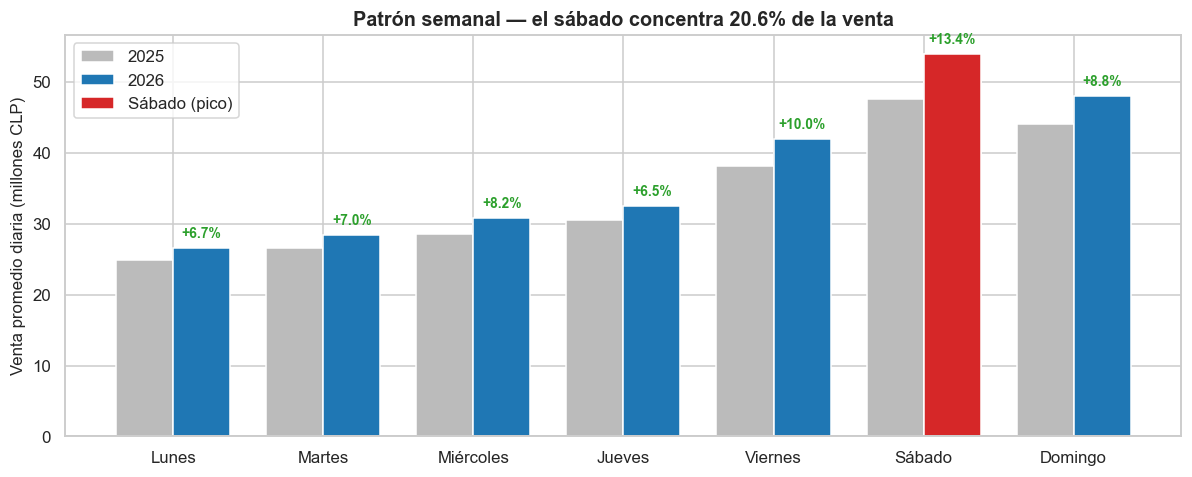

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x = range(len(r13))
width = 0.38
ax.bar([i-width/2 for i in x], r13['venta_prom_2025']/1e6, width,
       label='2025', color='#bbbbbb', edgecolor='white')
ax.bar([i+width/2 for i in x], r13['venta_prom_2026']/1e6, width,
       label='2026', color='#1f77b4', edgecolor='white')
# Destacar sábado
sab_idx = r13.index[r13['dia_semana']=='Sábado'][0]
ax.bar(sab_idx+width/2, r13.loc[sab_idx,'venta_prom_2026']/1e6, width,
       color='#d62728', edgecolor='white', label='Sábado (pico)')
ax.set_xticks(x)
ax.set_xticklabels(r13['dia_semana'])
ax.set_ylabel('Venta promedio diaria (millones CLP)')
ax.set_title('Patrón semanal — el sábado concentra 20.6% de la venta')
# YoY labels sobre barras 2026
for i, yoy in enumerate(r13['yoy_pct']):
    ax.text(i+width/2, r13.loc[i,'venta_prom_2026']/1e6 + 1.5,
            f'{yoy:+.1f}%', ha='center', fontsize=9, color='#2ca02c', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

**Insight:** El sábado concentra **20.6% de la venta semanal** y crece +13.4% YoY (la más alta). Sábado+domingo = 38.9% de la semana en solo 2 días. **Una hora de sábado vale 2× una hora de lunes** — staffing/reposición deben alinearse con esto.


## 1.4 Cumplimiento de presupuesto (con window function)


In [13]:
q14 = '''
WITH agg AS (
    SELECT v.cod_local, t.nombre_tienda, t.cadena,
           SUM(v.venta_neta)        AS venta_2026,
           SUM(p.presupuesto_venta) AS presup_2026,
           SUM(v.num_boletas)       AS boletas,
           SUM(tr.visitantes)       AS visitantes
    FROM ventas_final v
    JOIN tiendas t USING (cod_local)
    LEFT JOIN presupuesto p USING (fecha, cod_local)
    LEFT JOIN trafico_imputado tr USING (fecha, cod_local)
    WHERE strftime('%Y', v.fecha) = '2026'
    GROUP BY v.cod_local, t.nombre_tienda, t.cadena
)
SELECT cod_local, nombre_tienda, cadena,
       venta_2026, presup_2026,
       ROUND(venta_2026*100.0/NULLIF(presup_2026,0), 2) AS pct_cumplimiento,
       (venta_2026 - presup_2026) AS gap_clp,
       RANK() OVER (ORDER BY venta_2026*1.0/NULLIF(presup_2026,0) DESC) AS ranking,
       CASE WHEN venta_2026*1.0/NULLIF(presup_2026,0) >= 1.00 THEN 'Sobre meta'
            WHEN venta_2026*1.0/NULLIF(presup_2026,0) >= 0.90 THEN 'En riesgo'
            ELSE 'Bajo meta' END AS clasificacion,
       ROUND(boletas*100.0/NULLIF(visitantes,0), 2) AS conv_pct
FROM agg
ORDER BY pct_cumplimiento DESC;
'''
r14 = pd.read_sql(q14, conn)
r14_display = r14.copy()
for c in ['venta_2026','presup_2026','gap_clp']:
    r14_display[c] = r14_display[c].apply(clp)
r14_display['pct_cumplimiento'] = r14_display['pct_cumplimiento'].apply(lambda x: f"{x:.2f}%")
r14_display['conv_pct'] = r14_display['conv_pct'].apply(lambda x: f"{x:.2f}%")
display(r14_display)

,cod_local,nombre_tienda,cadena,venta_2026,presup_2026,pct_cumplimiento,gap_clp,ranking,clasificacion,conv_pct
0,T010,Urbana Costanera Center,Urbana,$51.987.277,$39.201.707,132.61%,$12.785.570,1,Sobre meta,19.91%
1,T011,Urbana Mall Sport,Urbana,$38.585.175,$29.181.913,132.22%,$9.403.262,2,Sobre meta,23.28%
2,T012,Urbana Plaza Egaña,Urbana,$21.215.203,$17.941.878,118.24%,$3.273.325,3,Sobre meta,19.44%
3,T009,Oceano Outlet Buenaventura,Oceano,$25.103.586,$22.625.306,110.95%,$2.478.280,4,Sobre meta,28.42%
4,T006,Summit Portal Ñuñoa,Summit,$28.174.242,$26.570.149,106.04%,$1.604.093,5,Sobre meta,20.19%
5,T002,Nordica Parque Arauco,Nordica,$68.245.321,$65.578.640,104.07%,$2.666.681,6,Sobre meta,19.53%
6,T001,Nordica Costanera Center,Nordica,$81.399.893,$79.087.469,102.92%,$2.312.424,7,Sobre meta,21.03%
7,T005,Summit Mall Plaza Trébol,Summit,$34.983.928,$36.274.626,96.44%,$-1.290.698,8,En riesgo,21.83%
8,T004,Summit Alto Las Condes,Summit,$57.491.910,$60.098.365,95.66%,$-2.606.455,9,En riesgo,17.54%
9,T003,Nordica Plaza Vespucio,Nordica,$44.957.819,$47.007.185,95.64%,$-2.049.366,10,En riesgo,24.31%


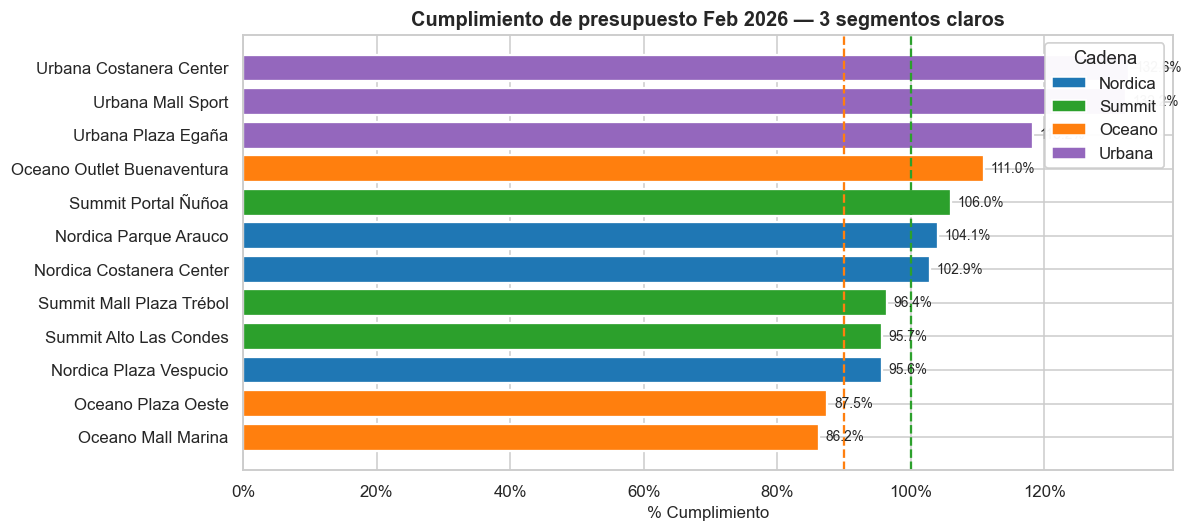

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
r14_sorted = r14.sort_values('pct_cumplimiento')
colors = [CHAIN_COLORS[c] for c in r14_sorted['cadena']]
y = range(len(r14_sorted))
bars = ax.barh(y, r14_sorted['pct_cumplimiento'], color=colors, edgecolor='white', linewidth=1.5)
ax.set_yticks(y)
ax.set_yticklabels(r14_sorted['nombre_tienda'])
# Thresholds
ax.axvline(100, color='#2ca02c', linestyle='--', linewidth=1.5, label='Meta (100%)')
ax.axvline(90,  color='#ff7f0e', linestyle='--', linewidth=1.5, label='En riesgo (90%)')
ax.set_xlabel('% Cumplimiento')
ax.set_title('Cumplimiento de presupuesto Feb 2026 — 3 segmentos claros')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
for bar, val in zip(bars, r14_sorted['pct_cumplimiento']):
    ax.text(val+1, bar.get_y()+bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=9)
ax.legend(loc='lower right')
# Leyenda de cadenas (manual)
from matplotlib.patches import Patch
chain_legend = [Patch(facecolor=c, label=n) for n, c in CHAIN_COLORS.items()]
leg2 = ax.legend(handles=chain_legend, loc='upper right', title='Cadena')
ax.add_artist(leg2)
plt.tight_layout()
plt.show()

**Insight:** 3 segmentos — **Overdeliverers** (Urbana domina top 3), **En riesgo ajustable** (Summit + 1 Nordica), **Bajo meta estructural** (T007 y T008 Oceano, gap combinado -$11M). T008 falla en convertir (17.7%), T007 NO — T007 falla en sostener ticket. Recomendaciones específicas por tienda en Parte 3.


---

# Parte 2 — Análisis Exploratorio (35 pts)

## 2.1 Anomalías en los datos

Ya identificadas en la limpieza inicial. Acá las visualizo y contextualizo estadísticamente.


In [15]:
# Outliers estadísticos intra-tienda (z-score)
ventas_pos = ventas_final[ventas_final['venta_neta'] >= 0].copy()
ventas_pos = ventas_pos.merge(tiendas[['cod_local','nombre_tienda','cadena']], on='cod_local')
ventas_pos['z_venta'] = ventas_pos.groupby('cod_local')['venta_neta'].transform(
    lambda s: (s - s.mean()) / s.std(ddof=0))
outliers = ventas_pos[ventas_pos['z_venta'].abs() > 2].sort_values('z_venta', ascending=False)
print(f"Outliers (|z|>2): {len(outliers)}")
display(outliers[['fecha','cod_local','nombre_tienda','venta_neta','z_venta']].assign(
    venta_neta=lambda d: d['venta_neta'].apply(clp),
    z_venta=lambda d: d['z_venta'].round(2)))

Outliers (|z|>2): 9


,fecha,cod_local,nombre_tienda,venta_neta,z_venta
240,2026-02-07,T001,Nordica Costanera Center,$11.152.080,3.43
249,2026-02-07,T010,Urbana Costanera Center,$6.818.530,3.29
242,2026-02-07,T003,Nordica Plaza Vespucio,$4.671.543,2.31
335,2026-02-14,T012,Urbana Plaza Egaña,$2.215.824,2.28
7,2025-02-01,T008,Oceano Plaza Oeste,$3.551.648,2.20
251,2026-02-07,T012,Urbana Plaza Egaña,$2.171.508,2.16
244,2026-02-07,T005,Summit Mall Plaza Trébol,$3.709.661,2.05
90,2025-02-08,T007,Oceano Mall Marina,$4.831.767,2.05
6,2025-02-01,T007,Oceano Mall Marina,$4.829.884,2.04


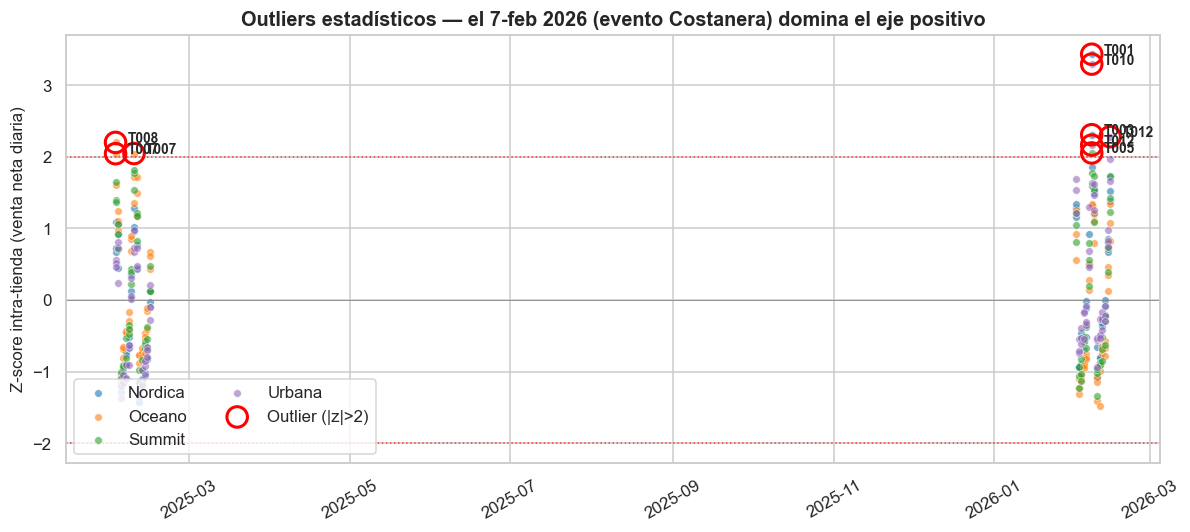

In [16]:
# Chart: z-score por día-tienda, marcando outliers (evento Costanera)
fig, ax = plt.subplots(figsize=(11, 5))
for cadena, grp in ventas_pos.groupby('cadena'):
    ax.scatter(grp['fecha'], grp['z_venta'], s=25, alpha=0.6,
               color=CHAIN_COLORS[cadena], label=cadena, edgecolors='white', linewidth=0.5)
# Destacar outliers
out_high = ventas_pos[ventas_pos['z_venta'] > 2]
ax.scatter(out_high['fecha'], out_high['z_venta'], s=180, facecolor='none',
           edgecolor='red', linewidth=2, label='Outlier (|z|>2)')
for _, row in out_high.iterrows():
    ax.annotate(row['cod_local'], (row['fecha'], row['z_venta']),
                xytext=(8, 0), textcoords='offset points', fontsize=9, fontweight='bold')
ax.axhline(2, color='red', linestyle=':', linewidth=1, alpha=0.7)
ax.axhline(-2, color='red', linestyle=':', linewidth=1, alpha=0.7)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('Z-score intra-tienda (venta neta diaria)')
ax.set_title('Outliers estadísticos — el 7-feb 2026 (evento Costanera) domina el eje positivo')
ax.legend(loc='lower left', ncol=2)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Hallazgos**:

| Anomalía | Tratamiento |
|---|---|
| A1 · Venta negativa T009 2026-02-10 (-$285K) | Agregada en venta neta diaria; flag `devoluciones` guardado |
| A2 · 3 nulls de tráfico T008 (05-07 feb) | Imputados con mediana DOW intra-tienda |
| A3 · Outliers z>+3 en T001 y T010 el 7-feb | **NO remover** — evento Costanera real (análisis en 2.3) |
| A4 · DDI extremo intra-cadena Oceano | T007=72.5d sobrestock vs T008=6.5d quiebre. No es error; flag operacional |
| A5 · Cobertura parcial `productos.csv` | Solo 4/12 tiendas. Conclusiones SKU-level limitadas a esas tiendas |

**Principio clave**: nunca aplicar detección automática de outliers sin contexto de negocio — si hubiera filtrado por z>2, habría perdido la pregunta más valiosa del challenge (el evento).


## 2.2 Diagnóstico cadena Oceano — descomposición de drivers

Oceano cae -9.86% YoY. Descompongo multiplicativamente:
$$\ln\left(\frac{V_{26}}{V_{25}}\right) = \ln\left(\frac{T_{26}}{T_{25}}\right) + \ln\left(\frac{C_{26}}{C_{25}}\right) + \ln\left(\frac{Ti_{26}}{Ti_{25}}\right)$$

Por la propiedad aditiva del logaritmo, los 3 drivers suman exactamente el total.


In [17]:
# Agregar por tienda y año
agg_yoy = (ventas_final.merge(tiendas, on='cod_local')
           .merge(trafico_imputado, on=['fecha','cod_local'])
           .assign(anio=lambda d: d['fecha'].dt.year)
           .groupby(['cod_local','nombre_tienda','cadena','anio'], as_index=False)
           .agg({'venta_neta':'sum', 'unidades':'sum',
                 'num_boletas':'sum', 'visitantes':'sum'}))

# Pivot
piv = agg_yoy.pivot_table(index=['cod_local','nombre_tienda','cadena'],
                          columns='anio',
                          values=['venta_neta','unidades','num_boletas','visitantes'])

def log_delta(n, p):
    return np.log(n/p) * 100

drivers = pd.DataFrame({
    'venta_2025': piv[('venta_neta', 2025)],
    'venta_2026': piv[('venta_neta', 2026)],
}).reset_index()

drivers['d_total'] = log_delta(piv[('venta_neta', 2026)].values, piv[('venta_neta', 2025)].values)
drivers['d_trafico'] = log_delta(piv[('visitantes', 2026)].values, piv[('visitantes', 2025)].values)
drivers['d_conv'] = log_delta(
    (piv[('num_boletas', 2026)]/piv[('visitantes', 2026)]).values,
    (piv[('num_boletas', 2025)]/piv[('visitantes', 2025)]).values)
drivers['d_ticket'] = log_delta(
    (piv[('venta_neta', 2026)]/piv[('num_boletas', 2026)]).values,
    (piv[('venta_neta', 2025)]/piv[('num_boletas', 2025)]).values)

oceano = drivers[drivers['cadena']=='Oceano'].copy()
display(oceano[['nombre_tienda','d_total','d_trafico','d_conv','d_ticket']].round(2)
        .rename(columns={'d_total':'Δ total %', 'd_trafico':'Δ tráfico %',
                         'd_conv':'Δ conv %', 'd_ticket':'Δ ticket %'}))
# Sanity: suma ≈ total
oceano['check'] = (oceano['d_trafico'] + oceano['d_conv'] + oceano['d_ticket']).round(2)
print(f"\nValidación aditiva: |Δtotal - (Δtráf+Δconv+Δtick)| max = "
      f"{(oceano['d_total']-oceano['check']).abs().max():.4f} pp")

,nombre_tienda,Δ total %,Δ tráfico %,Δ conv %,Δ ticket %
6,Oceano Mall Marina,-11.41,-5.60,3.37,-9.18
7,Oceano Plaza Oeste,-9.89,-5.02,0.96,-5.83
8,Oceano Outlet Buenaventura,-9.27,-8.97,3.36,-3.67



Validación aditiva: |Δtotal - (Δtráf+Δconv+Δtick)| max = 0.0024 pp


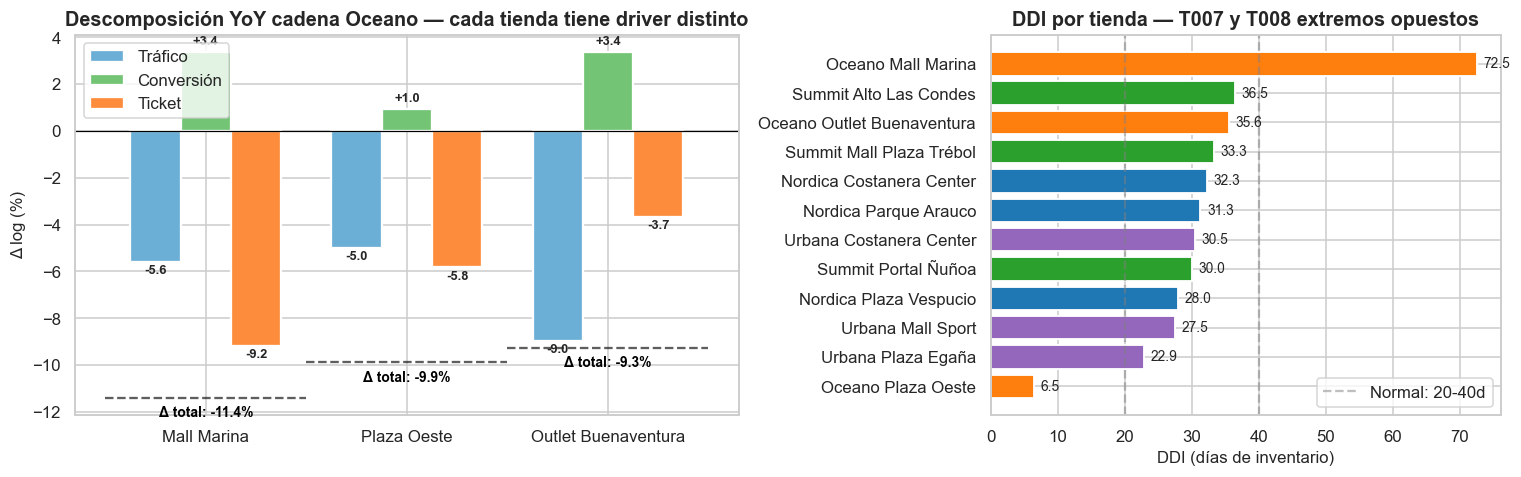

In [18]:
# Chart 1: descomposición log-delta por tienda Oceano
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5),
                                gridspec_kw={'width_ratios':[1.3, 1]})

# Barra apilada horizontal: drivers
oc_plot = oceano.set_index('nombre_tienda')[['d_trafico','d_conv','d_ticket']]
oc_plot.columns = ['Tráfico', 'Conversión', 'Ticket']
colors_dr = ['#6baed6', '#74c476', '#fd8d3c']
x = np.arange(len(oc_plot))
width = 0.25
for i, (col, color) in enumerate(zip(oc_plot.columns, colors_dr)):
    vals = oc_plot[col].values
    bars = ax1.bar(x + (i-1)*width, vals, width, color=color,
                   edgecolor='white', linewidth=1.5, label=col)
    for bar, v in zip(bars, vals):
        y_pos = v + 0.3 if v >= 0 else v - 0.5
        ax1.text(bar.get_x()+bar.get_width()/2, y_pos, f'{v:+.1f}',
                 ha='center', fontsize=8.5, fontweight='bold')

# Línea del total
for i, t in enumerate(oceano['d_total']):
    ax1.plot([i-0.5, i+0.5], [t, t], 'k--', linewidth=1.5, alpha=0.7)
    ax1.text(i, t-0.8, f'Δ total: {t:+.1f}%', ha='center', fontsize=9,
             fontweight='bold', color='black')

ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels([n.replace('Oceano ','') for n in oc_plot.index])
ax1.set_ylabel('Δ log (%)')
ax1.set_title('Descomposición YoY cadena Oceano — cada tienda tiene driver distinto')
ax1.legend(loc='upper left')

# Chart 2: DDI
inv_tiendas = inventario.merge(tiendas[['cod_local','nombre_tienda','cadena']], on='cod_local')
inv_tiendas['ddi'] = inv_tiendas['stock_unidades'] / inv_tiendas['venta_promedio_diaria_unidades']
inv_sort = inv_tiendas.sort_values('ddi')
colors_ddi = [CHAIN_COLORS[c] for c in inv_sort['cadena']]
bars = ax2.barh(inv_sort['nombre_tienda'], inv_sort['ddi'],
                color=colors_ddi, edgecolor='white', linewidth=1.2)
ax2.axvline(20, color='gray', linestyle='--', alpha=0.5, label='Normal: 20-40d')
ax2.axvline(40, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('DDI (días de inventario)')
ax2.set_title('DDI por tienda — T007 y T008 extremos opuestos')
for bar, v in zip(bars, inv_sort['ddi']):
    ax2.text(v+1, bar.get_y()+bar.get_height()/2, f'{v:.1f}',
             va='center', fontsize=9)
ax2.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Síntesis:**

- **T007 (DDI 72.5d)** · sobrestock, UPT -11.4%: inventario mal compuesto por temporada (parkas en verano ocupando el espacio de complementos).
- **T008 (DDI 6.5d)** · pipeline sub-dimensionado + mix caro que no rota.
- **T009 (Outlet)** · convierte 28.4% (la mejor de la red!), pero el tráfico cae -9% — atractivo outlet diluido.

La conversión **mejora en las 3 tiendas** → el problema no es el equipo de venta, es Planning/Allocation. Cruce con `productos.csv` de T007 confirma: 27.5% de la venta viene de parkas en febrero chileno.


In [19]:
# Mix T007 desde productos.csv
mix_t007 = (productos[productos['cod_local']=='T007']
            .groupby('clase', as_index=False)
            .agg({'unidades':'sum', 'venta_neta':'sum', 'costo':'sum'})
            .sort_values('venta_neta', ascending=False))
mix_t007['participacion'] = mix_t007['venta_neta']/mix_t007['venta_neta'].sum()*100
mix_t007['margen'] = (mix_t007['venta_neta']-mix_t007['costo'])/mix_t007['venta_neta']*100
display(mix_t007.assign(
    venta_neta=lambda d: d['venta_neta'].apply(clp),
    participacion=lambda d: d['participacion'].apply(lambda x: f"{x:.1f}%"),
    margen=lambda d: d['margen'].apply(lambda x: f"{x:.1f}%"),
))

,clase,unidades,venta_neta,costo,participacion,margen
3,Parkas,12,$1.577.089,744000,27.5%,52.8%
4,Poleras,39,$1.345.895,650500,23.4%,51.7%
1,Calzado,10,$913.669,420000,15.9%,54.0%
0,Accesorios,20,$895.370,360000,15.6%,59.8%
5,Shorts,30,$608.085,285000,10.6%,53.1%
2,Jeans,8,$400.934,192000,7.0%,52.1%


## 2.3 Evento Costanera — sábado 7-feb 2026

Tiendas afectadas: T001 (Nordica) y T010 (Urbana). Control principal: sábado 14-feb 2026. Controles YoY: sábados de febrero 2025.


In [20]:
tiendas_evento = ['T001','T010']
fechas_rel = ['2026-02-07', '2026-02-14', '2025-02-01', '2025-02-08']

ev = (ventas_final.merge(tiendas[['cod_local','nombre_tienda','cadena']], on='cod_local')
      .merge(trafico_imputado, on=['fecha','cod_local']))
ev = ev[(ev['cod_local'].isin(tiendas_evento)) &
        (ev['fecha'].dt.strftime('%Y-%m-%d').isin(fechas_rel))].copy()
ev['fecha_str'] = ev['fecha'].dt.strftime('%Y-%m-%d')
ev['conv_pct'] = ev['num_boletas']/ev['visitantes']*100
ev['ticket'] = ev['venta_neta']/ev['num_boletas']
ev['margen'] = (ev['venta_neta']-ev['costo'])/ev['venta_neta']*100

def tag(r):
    if r['fecha_str']=='2026-02-07': return 'EVENTO'
    if r['fecha_str']=='2026-02-14': return 'Control (sáb sig.)'
    return 'Control YoY'

ev['tipo'] = ev.apply(tag, axis=1)
ev_display = ev.sort_values(['cod_local','fecha_str'])[
    ['cod_local','fecha_str','tipo','venta_neta','visitantes','num_boletas','conv_pct','ticket','margen']].copy()
ev_display['venta_neta'] = ev_display['venta_neta'].apply(clp)
ev_display['ticket'] = ev_display['ticket'].apply(clp)
for c in ['conv_pct','margen']:
    ev_display[c] = ev_display[c].apply(lambda x: f"{x:.1f}%")
display(ev_display)

,cod_local,fecha_str,tipo,venta_neta,visitantes,num_boletas,conv_pct,ticket,margen
0,T001,2025-02-01,Control YoY,$6.481.749,500,97,19.4%,$66.822,45.0%
84,T001,2025-02-08,Control YoY,$6.976.960,431,109,25.3%,$64.009,45.0%
240,T001,2026-02-07,EVENTO,$11.152.080,798,133,16.7%,$83.850,45.0%
324,T001,2026-02-14,Control (sáb sig.),$7.683.936,475,114,24.0%,$67.403,45.0%
9,T010,2025-02-01,Control YoY,$3.868.783,330,73,22.1%,$52.997,50.0%
93,T010,2025-02-08,Control YoY,$3.990.880,317,73,23.0%,$54.670,50.0%
249,T010,2026-02-07,EVENTO,$6.818.530,621,102,16.4%,$66.848,50.0%
333,T010,2026-02-14,Control (sáb sig.),$5.054.116,403,81,20.1%,$62.396,50.0%


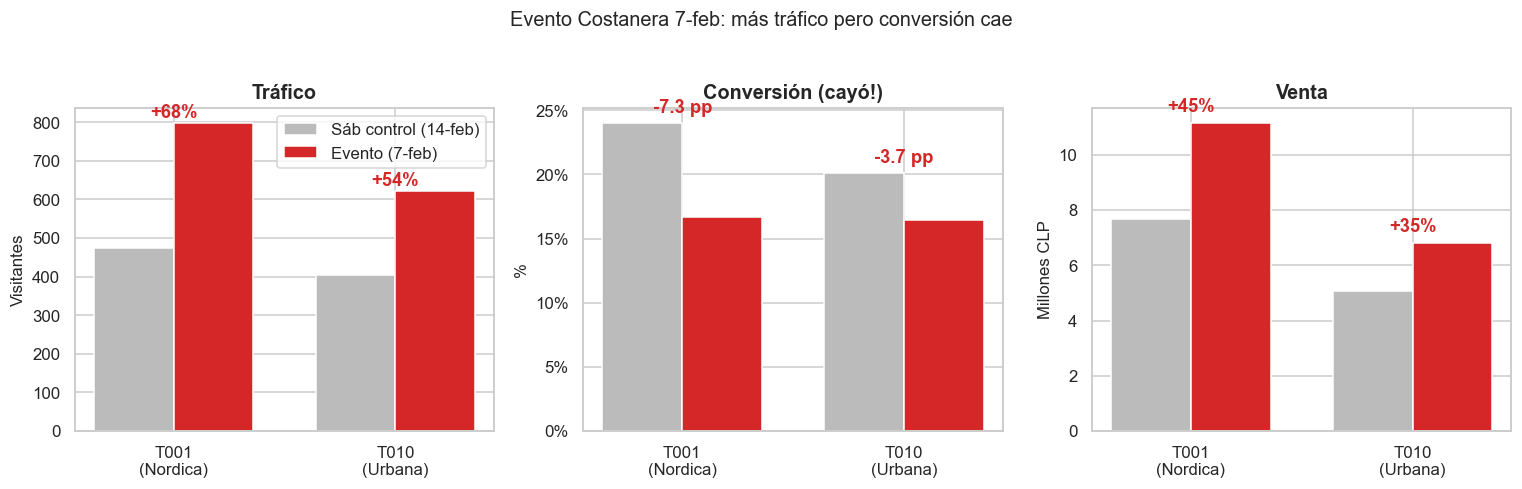

In [21]:
# Chart multi-panel: evento vs control
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
baseline = ev[ev['tipo']=='Control (sáb sig.)'].set_index('cod_local')
event = ev[ev['tipo']=='EVENTO'].set_index('cod_local')

labels = ['T001\n(Nordica)', 'T010\n(Urbana)']
x = np.arange(len(tiendas_evento))
w = 0.36

# Panel 1: Tráfico
ax = axes[0]
ax.bar(x-w/2, [baseline.loc[t,'visitantes'] for t in tiendas_evento],
       w, label='Sáb control (14-feb)', color='#bbbbbb')
ax.bar(x+w/2, [event.loc[t,'visitantes'] for t in tiendas_evento],
       w, label='Evento (7-feb)', color='#d62728')
for i, t in enumerate(tiendas_evento):
    delta = (event.loc[t,'visitantes']/baseline.loc[t,'visitantes'] - 1)*100
    ax.text(i, event.loc[t,'visitantes']+15, f'+{delta:.0f}%',
            ha='center', fontweight='bold', color='#d62728')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('Tráfico'); ax.set_ylabel('Visitantes'); ax.legend()

# Panel 2: Conversión
ax = axes[1]
ax.bar(x-w/2, [baseline.loc[t,'conv_pct'] for t in tiendas_evento],
       w, label='Sáb control', color='#bbbbbb')
ax.bar(x+w/2, [event.loc[t,'conv_pct'] for t in tiendas_evento],
       w, label='Evento', color='#d62728')
for i, t in enumerate(tiendas_evento):
    delta_pp = event.loc[t,'conv_pct'] - baseline.loc[t,'conv_pct']
    ax.text(i, max(event.loc[t,'conv_pct'], baseline.loc[t,'conv_pct'])+0.8,
            f'{delta_pp:+.1f} pp', ha='center', fontweight='bold', color='#d62728')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('Conversión (cayó!)'); ax.set_ylabel('%')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Panel 3: Venta
ax = axes[2]
ax.bar(x-w/2, [baseline.loc[t,'venta_neta']/1e6 for t in tiendas_evento],
       w, label='Sáb control', color='#bbbbbb')
ax.bar(x+w/2, [event.loc[t,'venta_neta']/1e6 for t in tiendas_evento],
       w, label='Evento', color='#d62728')
for i, t in enumerate(tiendas_evento):
    delta = (event.loc[t,'venta_neta']/baseline.loc[t,'venta_neta']-1)*100
    ax.text(i, event.loc[t,'venta_neta']/1e6+0.4, f'+{delta:.0f}%',
            ha='center', fontweight='bold', color='#d62728')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('Venta'); ax.set_ylabel('Millones CLP')

plt.suptitle('Evento Costanera 7-feb: más tráfico pero conversión cae', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

In [22]:
# Cuantificar valor perdido por caída de conversión
for t in tiendas_evento:
    conv_baseline = baseline.loc[t,'conv_pct']/100
    conv_evento = event.loc[t,'conv_pct']/100
    visitantes_evento = event.loc[t,'visitantes']
    ticket_evento = event.loc[t,'ticket']
    venta_evento = event.loc[t,'venta_neta']
    # Venta contrafactual: si hubiera mantenido la conversión baseline
    boletas_cf = visitantes_evento * conv_baseline
    venta_cf = boletas_cf * ticket_evento
    perdida = venta_cf - venta_evento
    print(f"{t}: conv evento {conv_evento*100:.1f}% vs baseline {conv_baseline*100:.1f}%")
    print(f"    Venta real {clp(venta_evento)} | Contrafactual {clp(venta_cf)} | Valor perdido {clp(perdida)}\n")

T001: conv evento 16.7% vs baseline 24.0%
    Venta real $11.152.080 | Contrafactual $16.058.995 | Valor perdido $4.906.915

T010: conv evento 16.4% vs baseline 20.1%
    Venta real $6.818.530 | Contrafactual $8.343.767 | Valor perdido $1.525.237



**Insight:**

- Evento generó **+$5.2M de venta** y **+$2.4M de margen bruto** en 1 día (vs sáb control).
- Pero conversión cayó 7.3 pp en T001, 3.7 pp en T010 → se dejaron **~$5.9M CLP sobre la mesa** por saturación operativa.
- **Sin canibalización**: el sáb siguiente (14-feb) también creció muy por sobre la cadena.
- Conclusión: los eventos Costanera son **comercialmente rentables pero operativamente imperfectos**. Doblar la apuesta en eventos, pero invertir primero en staffing/reposición (Recomendación 2).


---

# Parte 3 — Pensamiento de Negocio (25 pts)

## 3.1 Tres recomendaciones accionables (resumen)

### R1 · Re-componer el mix de Oceano (no solo redistribuir volumen)

- Transferir ~1.200 unidades T007 → T008 de categorías rotables (poleras, jeans, calzado ligero).
- Migrar parkas no vendidas de T007 a e-commerce con descuento controlado (-25 a -30%).
- Meta: DDI T008 6.5→28 días · DDI T007 72.5→45 días · recuperar ≥$6M de gap combinado.

### R2 · Playbook "evento de alta demanda" para proteger conversión

- Staffing +40% piso / +50% cajas; stock reforzado 48h antes; queue-busting con tablet en piso.
- Meta: próximo evento, sostener conversión ≥80% del baseline → +$3-4M CLP extra por evento en T001 solo.

### R3 · Plan driver-específico para Oceano

- **T007** (ticket): pricing reset post-redistribución.
- **T008** (mix/pipeline): protocolo de reposición jueves PM para best-sellers.
- **T009** (tráfico): campaña CRM de reactivación; análisis competitivo outlet.
- Meta global: frenar caída Oceano -9.86% → máximo -3% próxima quincena.

> Ver `challenge-andres-albornoz.md` para el detalle completo de cada recomendación.


---

# Bonus — Query e insight no preguntados

**Pregunta:** ¿qué tienda tiene la mejor "calidad de cliente"? (conv × ticket × UPT × margen)


In [23]:
q_bonus = '''
WITH m AS (
    SELECT t.cod_local, t.nombre_tienda, t.cadena, t.tipo_tienda,
           SUM(v.num_boletas)*1.0/NULLIF(SUM(tr.visitantes),0) AS conv,
           SUM(v.venta_neta)*1.0/NULLIF(SUM(v.num_boletas),0) AS ticket,
           SUM(v.unidades)*1.0/NULLIF(SUM(v.num_boletas),0)   AS upt,
           (SUM(v.venta_neta) - SUM(v.costo))*1.0/NULLIF(SUM(v.venta_neta),0) AS margen
    FROM tiendas t
    JOIN ventas_final v USING (cod_local)
    LEFT JOIN trafico_imputado tr USING (fecha, cod_local)
    WHERE strftime('%Y', v.fecha) = '2026'
    GROUP BY t.cod_local, t.nombre_tienda, t.cadena, t.tipo_tienda
)
SELECT cod_local, nombre_tienda, cadena, tipo_tienda,
       ROUND(conv*100, 2) AS conv_pct,
       ROUND(ticket, 0)   AS ticket,
       ROUND(upt, 2)      AS upt,
       ROUND(margen*100, 2) AS margen_pct,
       ROUND(conv*ticket*upt*margen, 0) AS quality_score
FROM m ORDER BY quality_score DESC;
'''
rb = pd.read_sql(q_bonus, conn)
rb_display = rb.copy()
rb_display['ticket'] = rb_display['ticket'].apply(clp)
for c in ['conv_pct','margen_pct']:
    rb_display[c] = rb_display[c].apply(lambda x: f"{x:.2f}%")
display(rb_display)

,cod_local,nombre_tienda,cadena,tipo_tienda,conv_pct,ticket,upt,margen_pct,quality_score
0,T001,Nordica Costanera Center,Nordica,retail,21.03%,$72.874,1.67,45.00%,11538.0
1,T002,Nordica Parque Arauco,Nordica,retail,19.53%,$72.217,1.70,45.00%,10819.0
2,T003,Nordica Plaza Vespucio,Nordica,retail,24.31%,$54.693,1.70,45.00%,10174.0
3,T010,Urbana Costanera Center,Urbana,retail,19.91%,$60.875,1.63,50.00%,9886.0
4,T011,Urbana Mall Sport,Urbana,retail,23.28%,$53.965,1.57,50.00%,9867.0
5,T004,Summit Alto Las Condes,Summit,retail,17.54%,$75.847,1.52,48.00%,9689.0
6,T005,Summit Mall Plaza Trébol,Summit,retail,21.83%,$55.618,1.58,48.00%,9220.0
7,T006,Summit Portal Ñuñoa,Summit,retail,20.19%,$53.870,1.61,48.00%,8423.0
8,T007,Oceano Mall Marina,Oceano,retail,20.21%,$58.660,1.52,42.00%,7562.0
9,T012,Urbana Plaza Egaña,Urbana,retail,19.44%,$49.684,1.55,50.00%,7478.0


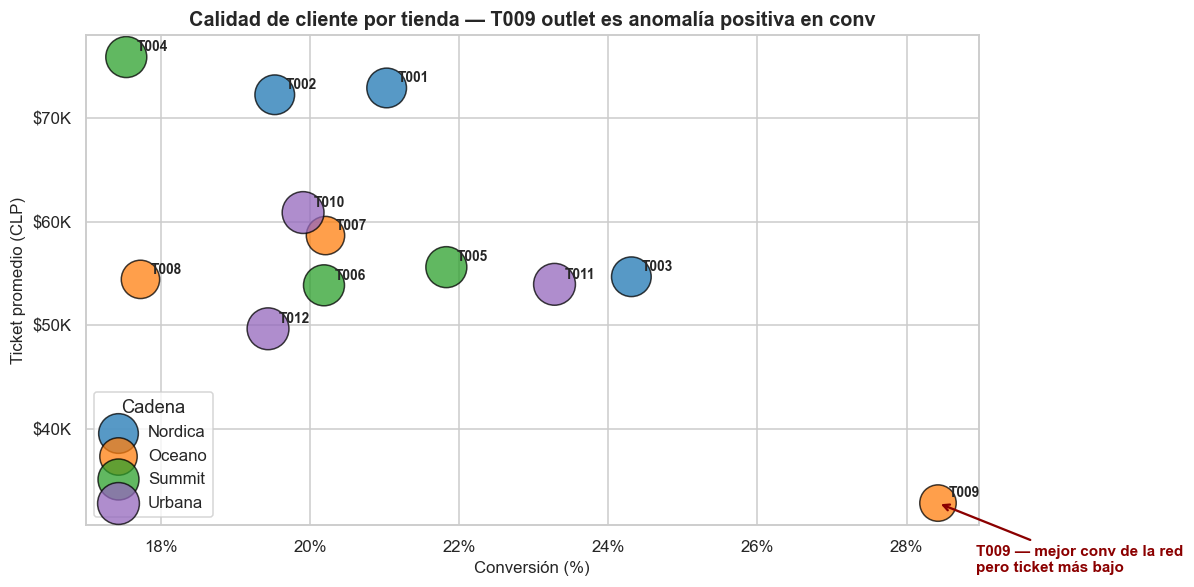

In [24]:
# Chart: scatter conv × ticket, tamaño por margen, color por cadena
fig, ax = plt.subplots(figsize=(11, 5.5))
for cadena, grp in rb.groupby('cadena'):
    ax.scatter(grp['conv_pct'], grp['ticket'], s=grp['margen_pct']*15,
               color=CHAIN_COLORS[cadena], edgecolors='black', linewidth=1,
               alpha=0.75, label=cadena)
for _, row in rb.iterrows():
    ax.annotate(row['cod_local'], (row['conv_pct'], row['ticket']),
                xytext=(7, 4), textcoords='offset points', fontsize=9, fontweight='bold')

# Destacar T009 — mejor conv, ticket bajo
t009 = rb[rb['cod_local']=='T009'].iloc[0]
ax.annotate('T009 — mejor conv de la red\npero ticket más bajo',
            xy=(t009['conv_pct'], t009['ticket']),
            xytext=(25, -45), textcoords='offset points',
            fontsize=10, fontweight='bold', color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

ax.set_xlabel('Conversión (%)')
ax.set_ylabel('Ticket promedio (CLP)')
ax.set_title('Calidad de cliente por tienda — T009 outlet es anomalía positiva en conv')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(title='Cadena', loc='lower left')
plt.tight_layout()
plt.show()

**Insight no obvio:**

**T009 Outlet Buenaventura tiene la mejor conversión de toda la red (28.4%)** — más alta incluso que T003 (24.3%) y el doble que T004 (17.5%). Cuando alguien entra al outlet, **compra**. Pero su ticket ($32.901) y margen (37.95%) son los más bajos, por eso queda último en quality score.

**Oportunidad estratégica**: subir ticket de T009 de $32.901 → $40.000 manteniendo conversión significaría **+$5.4M CLP en la quincena**, más que el gap total de Summit Mall Plaza Trébol. El problema de T009 no es el piso de venta (convierte excelente), es **llevar gente al local**. La acción prioritaria es generar tráfico, no eficiencia.


---

## Reproducibilidad

- Repo: https://github.com/Andressac25/forus-challenge
- Notebook en Colab: [challenge.ipynb](https://colab.research.google.com/github/Andressac25/forus-challenge/blob/main/notebooks/challenge.ipynb)
- Entregable completo: [`challenge-andres-albornoz.md`](../challenge-andres-albornoz.md)
- Dashboard Streamlit: [`src/dashboard.py`](../src/dashboard.py)

```bash
pip install pandas numpy matplotlib seaborn jupyter ipykernel
jupyter lab notebooks/challenge.ipynb
```
